In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor()])

# Download and load the training data
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

In [ ]:
len(train_data)

In [ ]:
import matplotlib.pyplot as plt

image, label = train_data[0]
print(f"Label: {label}")
plt.imshow(image.squeeze(), cmap='gray')
plt.show()

In [4]:
image.shape

torch.Size([1, 28, 28])

In [5]:
from torch import nn

class network(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(28 * 28, 128)
        self.l2 = nn.Linear(128, 32)
        self.l3 = nn.Linear(32, 10)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Flatten the input
        x = nn.functional.relu(self.l1(x))
        x = nn.functional.relu(self.l2(x))
        x = self.l3(x)
        return x

In [7]:
import torch

net = network()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

In [21]:

train_data[0][0].shape
train_data[0][1]
train_data.train_data[0]

e:\VS Code Project\ML\.venv\Lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [13]:
dir(train_data)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_exists',
 '_check_legacy_exist',
 '_format_transform_repr',
 '_load_data',
 '_load_legacy_data',
 '_repr_indent',
 'class_to_idx',
 'classes',
 'data',
 'download',
 'extra_repr',
 'mirrors',
 'processed_folder',
 'raw_folder',
 'resources',
 'root',
 'target_transform',
 'targets',
 'test_data',
 'test_file',
 'test_labels',
 'train',
 'train_data',
 'train_labels',
 'training_file',
 'transform',
 'transforms']

In [15]:
train_data.train_labels[0]

tensor(5)

In [24]:
epochs = 100
batch_size = 64

for epoch in range(epochs):
    for i in range(0, len(train_data), batch_size):
        images, labels = train_data.train_data[i:i+batch_size], train_data.train_labels[i:i+batch_size]
        # print(images.dtype)
        # image shape = batch_size x 28*28
        # label shape = batch_size x 1
        output = net(images.float())
        # output shape = batch_size x 10
        loss = loss_fn(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 0.0083
Epoch 2/100, Loss: 0.0169
Epoch 3/100, Loss: 0.0075
Epoch 4/100, Loss: 0.0038
Epoch 5/100, Loss: 0.0046
Epoch 6/100, Loss: 0.0800
Epoch 7/100, Loss: 0.0135
Epoch 8/100, Loss: 0.0073
Epoch 9/100, Loss: 0.0045
Epoch 10/100, Loss: 0.0032
Epoch 11/100, Loss: 0.0387
Epoch 12/100, Loss: 0.0096
Epoch 13/100, Loss: 0.0053
Epoch 14/100, Loss: 0.0218
Epoch 15/100, Loss: 0.0308
Epoch 16/100, Loss: 0.0356
Epoch 17/100, Loss: 0.0250
Epoch 18/100, Loss: 0.0134
Epoch 19/100, Loss: 0.0149
Epoch 20/100, Loss: 0.0096
Epoch 21/100, Loss: 0.0309
Epoch 22/100, Loss: 0.0305
Epoch 23/100, Loss: 0.0082
Epoch 24/100, Loss: 0.0044
Epoch 25/100, Loss: 0.0058
Epoch 26/100, Loss: 0.0053
Epoch 27/100, Loss: 0.1616
Epoch 28/100, Loss: 0.0201
Epoch 29/100, Loss: 0.0047
Epoch 30/100, Loss: 0.0051
Epoch 31/100, Loss: 0.0179
Epoch 32/100, Loss: 0.0094
Epoch 33/100, Loss: 0.0333
Epoch 34/100, Loss: 0.0059
Epoch 35/100, Loss: 0.0047
Epoch 36/100, Loss: 0.0195
Epoch 37/100, Loss: 0.0015
Epoch 38/1

In [25]:
net.eval()


network(
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=32, bias=True)
  (l3): Linear(in_features=32, out_features=10, bias=True)
)

e:\VS Code Project\ML\.venv\Lib\site-packages\torchvision\datasets\mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
e:\VS Code Project\ML\.venv\Lib\site-packages\torchvision\datasets\mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


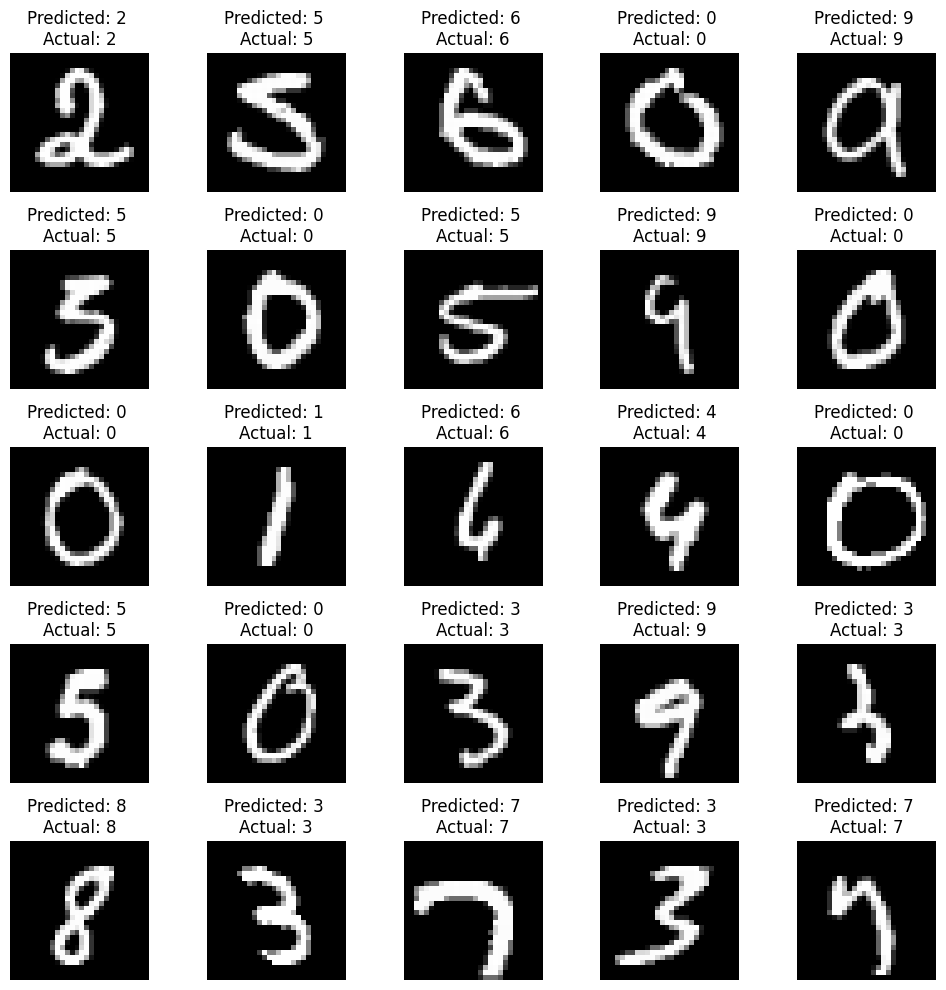

In [34]:
ROWS = 5
COLS = 5

import random
index = [random.randint(0, len(train_data)-1) for _ in range(COLS * ROWS)]
test_data = train_data.test_data[index]
test_labels = train_data.test_labels[index]

test_output = net(test_data.float())
_, predicted_labels = torch.max(test_output, 1)

plt.subplots(ROWS, COLS, figsize=(10, 10))
for row in range(ROWS):
    for col in range(COLS):
        plt.subplot(ROWS, COLS, row * COLS + col + 1)
        plt.imshow(test_data[row * COLS + col].reshape(28, 28), cmap='gray')
        plt.title(f"Predicted: {predicted_labels[row * COLS + col]} \nActual: {test_labels[row * COLS + col]}")
        plt.axis('off')
plt.tight_layout()
